In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def admissibility_split(MP, a, return_P=False, subspace=False, consistency = True, with_edges=False):
    level={1:5, 2:5, 3:5, 4:5, 5:5, 6:5, 7:5}
    marked = set()
    mapped = lambda x: 1 if x in (0, 1) else 0
    num_split=0
    assert isinstance(a,dict) and len(a)==len(MP.mesh.domains), 'Invalid type for diffusion coefficient'
    if return_P:
        P = scipy.sparse.identity(MP.nLocDofs)
    while True:
        for p in range(MP.mesh.numpatches):
            for b in range(4):
                kv = MP.mesh.kvs[p][mapped(b)]
                deg = kv.p
                s1,s2 = kv.support()
                nodes = np.clip(MP.mesh.boundaries(p)[1][b],kv.kv[0],kv.kv[-1])
                m = min(nodes[1:]-nodes[:-1])
                if not bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes), with_edges) or (s2-s1)/m>2**level[deg]-1:
                    marked.add(p)
        if consistency:
            for (p1,b1) in MP.mesh.L_intfs:
                if len(MP.mesh.L_intfs[(p1,b1)])>1:
                    p2 = MP.mesh.L_intfs[(p1,b1)][0][0]
                    if a[MP.mesh.patch_domains[p1]] + 1e-3 < a[MP.mesh.patch_domains[p2]]:
                        marked.add(p1)
        if len(marked)>0:
            num_split+=len(marked)
            if return_P:
                P = MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace) @ P
            else:
                MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace)
            marked=set()
        else:
            break
    if consistency:
        print("Split {} additional patches due to admissibility and consistency".format(num_split))
    else:
        print("Split {} additional patches due to admissibility".format(num_split))
    if return_P:
        return P

In [4]:
def Inductor(deg,N, airgap=0.025):
    kvs=42*[2*(bspline.make_knots(deg,0.0,1.0,N),)]
    
    geos=[      
        geometry.unit_square().scale((0.5)).translate((-0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,-0.5)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,-0.5)),
        geometry.unit_square().scale(0.5).translate((1.5,-0.5)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0)),
        geometry.unit_square().scale(0.25),
        geometry.unit_square().scale(0.25).translate((0.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0)),
        
        geometry.unit_square().scale((0.5,airgap)).translate((-0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((1.5,0.25)),
        
        geometry.unit_square().scale((0.5,0.5)).translate((-0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((1.5,0.25+airgap)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0.75+airgap)),
        
        geometry.unit_square().scale(0.5).translate((-0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,1.0+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,1.0+airgap)),
        geometry.unit_square().scale(0.5).translate((1.5,1.0+airgap)),
         ]
    patches=list(zip(kvs,geos))
    M = topology.MultiPatch(patches)
    M.rename_domain(0,'Air')
    M.set_domain_id({'Fe':{8,9,10,11,12,22,24,26,29,30,31,32,33}, 'C1':{23}, 'C2':{25}})
    M.h_refine({i:1 for i in range(14,21)});                                        #split airgap patches further in y-axis to make up for anisotropy 
    M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))});               #split airgap patches further in y-axis to make up for anisotropy 
    #M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))+list(range(49,63))}); #split airgap patches further in y-axis to make up for anisotropy
    return M

In [5]:
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
j = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}
MaT = {'C1': lambda x,y: (0.,0.), 'C2': lambda x,y:(0.,0.), 'Fe':lambda x,y:(0.,0.), 'Air': lambda x,y:(0.,0.)}
dir_data = {0:0}

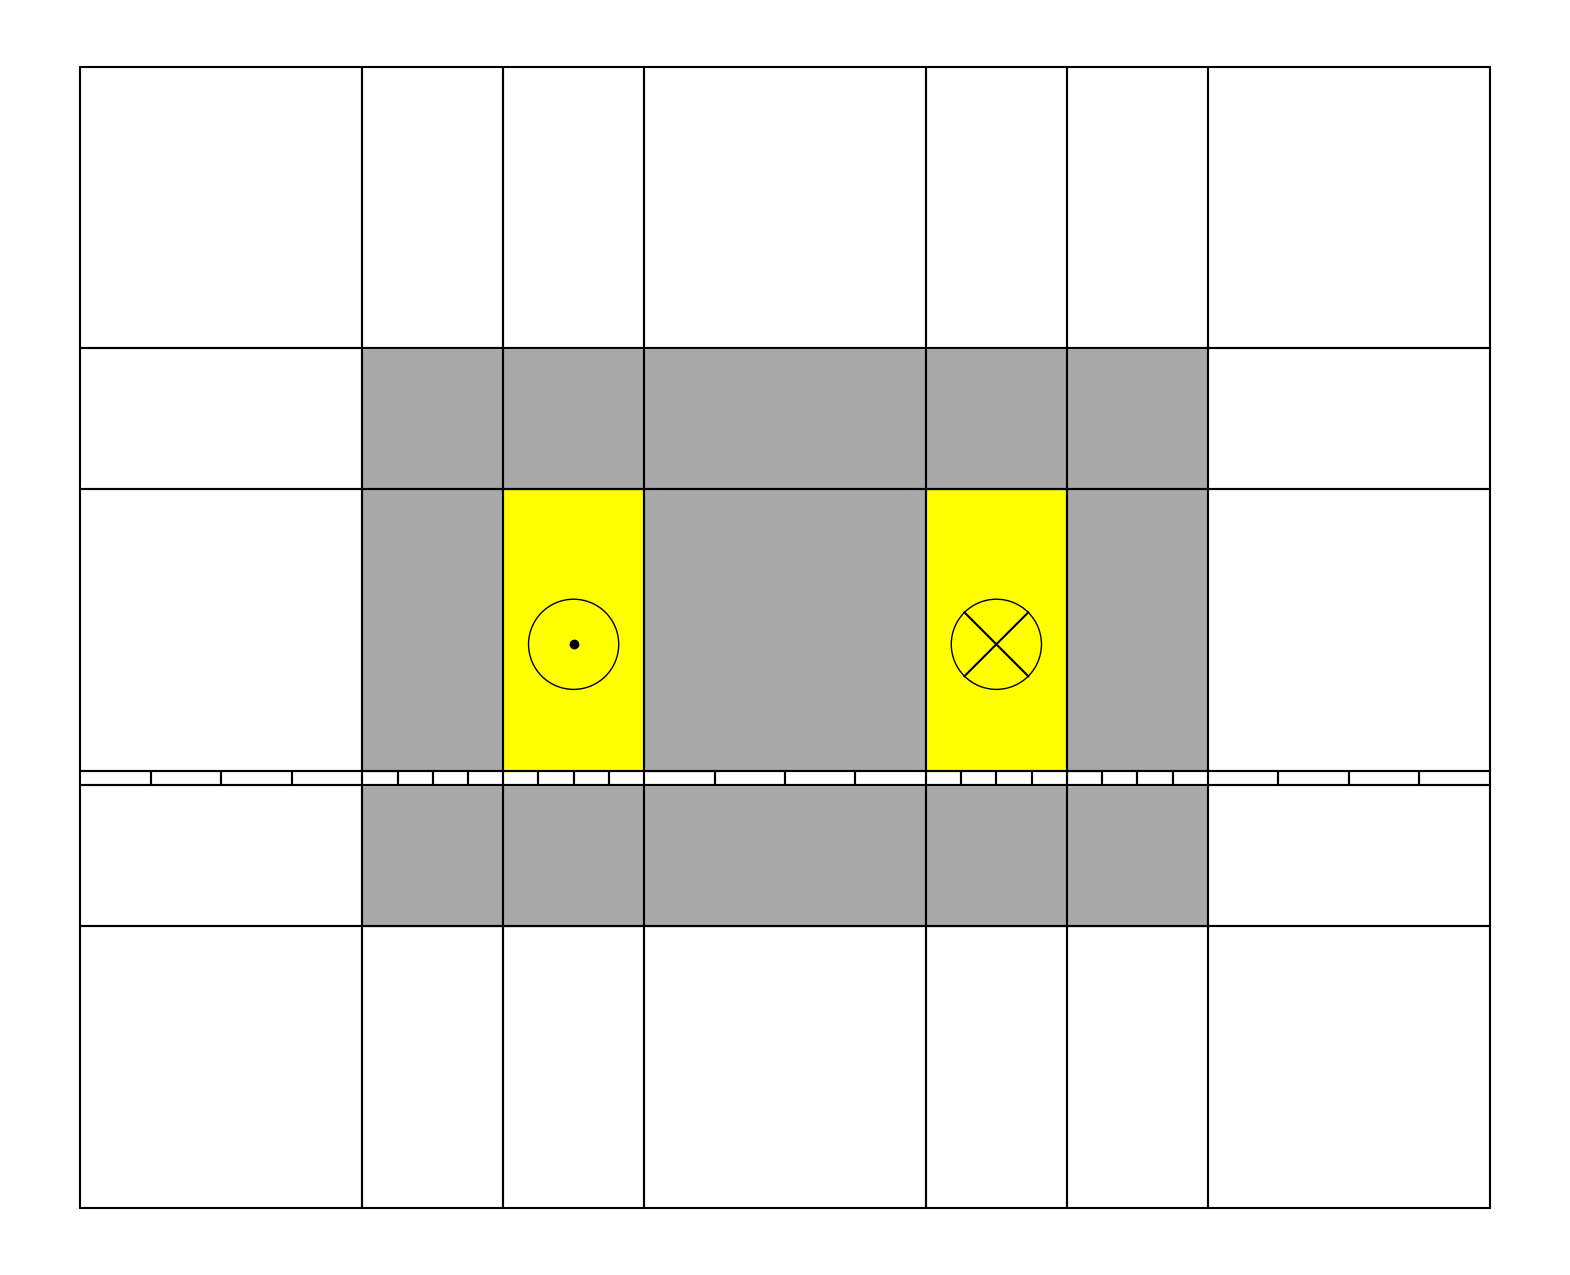

In [7]:
M = Inductor(2,5, airgap=0.025)
M.plotmesh(figsize=(20,20),color={'C1':'yellow', 'C2':'yellow', 'Fe':'darkgrey', 'Air':'white'}, knots=0, bwidth=0.01, patch_idx=0)
r=0.08
plt.gca().add_patch(plt.Circle((0.375, 0.5), r, fill=False))
plt.plot(0.375, 0.5, 'o', color="black")
plt.gca().add_patch(plt.Circle((1.125, 0.5), r, fill=False))
plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5+r/np.sqrt(2), 0.5-r/np.sqrt(2)], color="black")
plt.plot([1.125-r/np.sqrt(2), 1.125+r/np.sqrt(2)], [0.5-r/np.sqrt(2),0.5+r/np.sqrt(2)], color="black")
#plt.plot([0, 0], [-r, r])  # vertical
plt.axis('off');
plt.axis('scaled');
#plt.show()
#plt.savefig('/home/wolfman/Pictures/Inductor_material.pdf',bbox_inches='tight');

In [ ]:
degs = (2,3,5,8)
maxpatches =(5000,4000,3000,2000)
#maxiter=(7,7,7,6)
maxiter=4*(50,)
eps=(1e-5,1e-6,1e-7,1e-8)
plot=1
uniform=False


R = np.zeros((max(maxiter),len(degs)*5))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    if example==0:
        M = Lshape(deg,N,1)
    elif example==1:
        M = LshapeAnullus(deg,N,1)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    U=[]
    k=0
    while k<maxiter[i]:
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            if example==0:
                plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            elif example==1:
                plt.savefig('/mnt/c/Users/stefa/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*5] = MB.nDofs
        R[k,i*5+1] = MB.nPatches
        
        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)

        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)
        U.append(uh)
        if exact:
            Mh = MB.assemble_volume("u * v * dx", arity=2, domain_id=0)
            Uh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u)
            u_exact = operators.make_solver(Mh,spd=True)@Uh

            eh = uh - u_exact
            Eerr = np.sqrt(eh@Kh@eh)
            R[k,i*5+2] = Eerr
            
        #MB.plot(uh, mesh=True)
        #plt.show();

        if not uniform:
            err_ind=adaptive.mp_resPois(MB, uh, nu=1, f=f)
            eta = np.linalg.norm(err_ind)
            R[k,i*5+3] = eta
        
        if exact:
            eh = uh - u_exact
            Eerr = np.sqrt(eh@Kh@eh)
            R[k,i*5+2] = Eerr

            if not uniform:
                R[k,i*5+4] = eta/Eerr

        # print(Eerr)
        print(eta)
        # print(eta/Eerr)

        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps[i]:
            break;

        if not uniform:
            P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = not exact, in_subspace=True)
        else:
            P = MB.h_refine(h_ref=-1,ref="rs", return_P = not exact, in_subspace=True)

        if not exact:
            for j in range(len(U)):
                U[j]=P@U[j]
        k+=1
    if not exact:
        P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
        P = MB.p_refine(1, return_P = True, in_subspace=True)@P

        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        u_exact = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        for j in range(len(U)):
            eh = u_exact - P@U[j]
            Eerr = np.sqrt(eh@Kh@eh)
            R[j,i*5+2] = Eerr
            R[j,i*5+4] = R[j,i*5+3]/Eerr
        
if example==0:
    if uniform:
        np.save('Lshape_uniform',R)
    else:
        np.save('Lshape_adaptive',R)
elif example==1:
    if uniform:
        np.save('LshapeQ_uniform',R)
    else:
        np.save('LshapeQ_adaptive',R)